Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.3629 - loss: 2.0781 - val_accuracy: 0.5833 - val_loss: 1.8717
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6815 - loss: 1.5698 - val_accuracy: 0.7639 - val_loss: 1.3098
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8242 - loss: 1.0142 - val_accuracy: 0.8785 - val_loss: 0.8106
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8799 - loss: 0.6365 - val_accuracy: 0.9062 - val_loss: 0.5475
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9104 - loss: 0.4357 - val_accuracy: 0.9097 - val_loss: 0.4193
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9382 - loss: 0.3252 - val_accuracy: 0.9201 - val_loss: 0.3432
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9478 - loss: 0.2553 - val_accuracy: 0.9201 - val_loss: 0.3047
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9574 - loss: 0.2186 - val_accuracy: 0.9306 - 

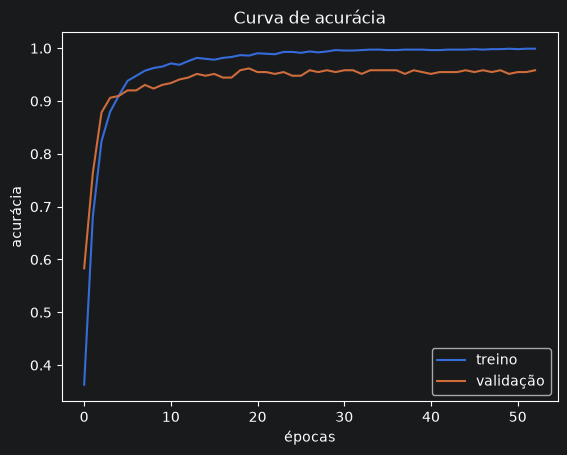

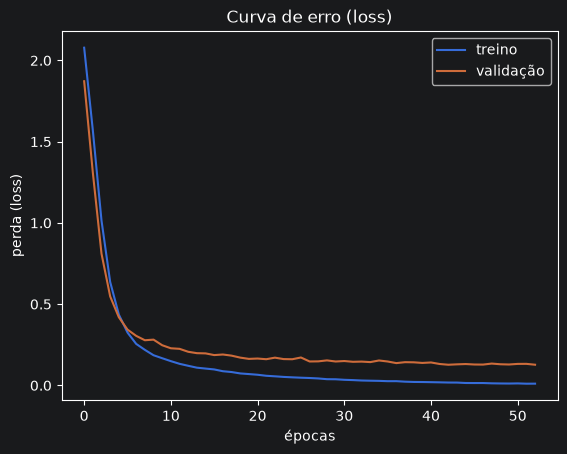

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
from tensorflow import keras
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

dados = load_digits()
x = dados.data / 16.0
y = dados.target

x_treino, x_test, y_treino, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

modelo = keras.Sequential([
    keras.layers.Input(shape=(64,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(10, activation='softmax'),
])
modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

parada_antecipada = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

historico = modelo.fit(
    x_treino, y_treino,
    epochs=100, batch_size=32,
    validation_split=0.2,
    callbacks=[parada_antecipada]
)

epoca_parada = len(historico.history['loss'])
print("Parou na epoca: ", epoca_parada)

# Gráfico 1: acurácia (treino vs validação)
plt.figure()
plt.plot(historico.history['accuracy'], label='treino')
plt.plot(historico.history['val_accuracy'], label='validação')
plt.xlabel('épocas'); plt.ylabel('acurácia'); plt.legend()
plt.title('Curva de acurácia')
plt.savefig('curvas_aprendizado.png')

# Gráfico 2: perda / erro (treino vs validação)
plt.figure()
plt.plot(historico.history['loss'], label='treino')
plt.plot(historico.history['val_loss'], label='validação')
plt.xlabel('épocas'); plt.ylabel('perda (loss)'); plt.legend()
plt.title('Curva de erro (loss)')
plt.savefig('curvas_erro.png')

perda, acuracia = modelo.evaluate(x_test, y_test, verbose=0)
print("Acuracia no teste: ", round(acuracia, 3))
print("Perda no teste: ", round(perda, 3))